<h2>Creating Class-wise Unlearnable Examples</h2>

In [1]:
import multiprocessing
print(multiprocessing.cpu_count())  # 查看你的 CPU 核心数

12


<h3>Prepare Data</h3>

In [2]:
import os
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Prepare Dataset
train_transform = [
    transforms.ToTensor()
]
test_transform = [
    transforms.ToTensor()
]
train_transform = transforms.Compose(train_transform)
test_transform = transforms.Compose(test_transform)

clean_train_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=True, download=True, transform=train_transform)
clean_test_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=False, download=True, transform=test_transform)

clean_train_loader = DataLoader(dataset=clean_train_dataset, batch_size=256,
                                shuffle=False, pin_memory=True,
                                drop_last=False, num_workers=6)
clean_test_loader = DataLoader(dataset=clean_test_dataset, batch_size=256,
                                shuffle=False, pin_memory=True,
                                drop_last=False, num_workers=6)

c:\Users\desktop\Often\conda\envs\gpu\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


<h3>Prepare Model</h3>

In [3]:
from models.ResNet import ResNet18

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

base_model = ResNet18()
base_model = base_model.cuda()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=base_model.parameters(), lr=0.1, weight_decay=0.0005, momentum=0.9)



c:\Users\desktop\Often\conda\envs\gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h3>Prepare Perturbation Generator Tool</h3>

In [4]:
import numpy as np
from torch.autograd import Variable

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

class PerturbationTool():
    def __init__(self, seed=0, epsilon=0.03137254901, num_steps=20, step_size=0.00784313725):
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.step_size = step_size
        self.seed = seed
        np.random.seed(seed)

    def random_noise(self, noise_shape=[10, 3, 32, 32]):
        random_noise = torch.FloatTensor(*noise_shape).uniform_(-self.epsilon, self.epsilon).to(device)
        return random_noise

    def min_min_attack(self, images, labels, model, optimizer, criterion, random_noise=None, sample_wise=False):
        if random_noise is None:
            random_noise = torch.FloatTensor(*images.shape).uniform_(-self.epsilon, self.epsilon).to(device)

        perturb_img = Variable(images.data + random_noise, requires_grad=True)
        perturb_img = Variable(torch.clamp(perturb_img, 0, 1), requires_grad=True)
        eta = random_noise
        for _ in range(self.num_steps):
            opt = torch.optim.SGD([perturb_img], lr=1e-3)
            opt.zero_grad()
            model.zero_grad()
            if isinstance(criterion, torch.nn.CrossEntropyLoss):
                if hasattr(model, 'classify'):
                    model.classify = True
                logits = model(perturb_img)
                loss = criterion(logits, labels)
            else:
                logits, loss = criterion(model, perturb_img, labels, optimizer)
            perturb_img.retain_grad()
            loss.backward()
            eta = self.step_size * perturb_img.grad.data.sign() * (-1)
            perturb_img = Variable(perturb_img.data + eta, requires_grad=True)
            eta = torch.clamp(perturb_img.data - images.data, -self.epsilon, self.epsilon)
            perturb_img = Variable(images.data + eta, requires_grad=True)
            perturb_img = Variable(torch.clamp(perturb_img, 0, 1), requires_grad=True)

        return perturb_img, eta

    
noise_generator = PerturbationTool(epsilon=16/255, num_steps=10, step_size=4/255)


### Test noise_generator
images= torch.randn([1,3,32,32]).cuda()
labels= torch.ones([1]).long().cuda()

# noise_generator.min_min_attack(images, labels, base_model, optimizer, criterion, 
#                                                           random_noise=torch.zeros_like(images).cuda())


Using device: cuda


<h3>Generate Class-wise Error-Minimizing Noise</h3>

In [5]:
from tqdm import tqdm
import torch

noise = torch.zeros([10, 3, 32, 32], device=device)

data_iter = iter(clean_train_loader)
condition = True

while condition:
    # ========== 阶段1：训练 10 个 batch ==========
    base_model.train()
    for param in base_model.parameters():
        param.requires_grad = True
    
    for j in range(10):
        images, labels = next(data_iter)
        images, labels = images.cuda(), labels.cuda()
        
        # 加噪声并 clamp
        images = torch.clamp(images + noise[labels], 0, 1)
        
        logits = base_model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"training one batch!")
    
    print(f"Finish training base model for 10 steps, start perturbation...")

    # ========== 阶段2：更新噪声 ==========
    for param in base_model.parameters():
        param.requires_grad = False
    
    for images, labels in tqdm(clean_train_loader, total=len(clean_train_loader)):
        images, labels = images.cuda(), labels.cuda()
        batch_noise = noise[labels]
        
        base_model.eval()
        perturb_img, eta = noise_generator.min_min_attack(
            images, labels, base_model, optimizer, criterion, 
            random_noise=batch_noise
        )
        
        # ✅ 性能优化：用 index_add_ 代替循环
        noise.index_add_(0, labels, eta.detach())
        noise = torch.clamp(noise, -noise_generator.epsilon, noise_generator.epsilon)
        
        print(f"compute all noise for one batch!")

    print(f"Finish perturbation, start evaluation...")

    # ========== 阶段3：评估 ==========
    total, correct = 0, 0
    with torch.no_grad():
        for images, labels in clean_train_loader:
            images, labels = images.cuda(), labels.cuda()
            images = torch.clamp(images + noise[labels], 0, 1)
            
            logits = base_model(images)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = correct / total
    print(f'Accuracy: {acc*100:.2f}%')
    
    if acc > 0.9:
        condition = False

training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
training one batch!
Finish training base model for 10 steps, start perturbation...


  1%|          | 1/196 [00:20<1:07:30, 20.77s/it]

compute all noise for one batch!


  1%|          | 2/196 [00:21<28:25,  8.79s/it]  

compute all noise for one batch!


...

compute all noise for one batch!


100%|██████████| 196/196 [02:16<00:00,  1.93it/s]

compute all noise for one batch!


100%|██████████| 196/196 [02:17<00:00,  1.43it/s]


Finish perturbation, start evaluation...
Accuracy: 96.90%


In [6]:
# Examine the noise
print(noise)

tensor([[[[-0.0627, -0.0627, -0.0627,  ..., -0.0627, -0.0627, -0.0627],
          [-0.0627,  0.0627, -0.0627,  ...,  0.0627, -0.0627, -0.0627],
          [-0.0627, -0.0627, -0.0627,  ..., -0.0627, -0.0627, -0.0627],
          ...,
          [-0.0627,  0.0627, -0.0627,  ..., -0.0627, -0.0627, -0.0627],
          [-0.0627, -0.0627, -0.0627,  ..., -0.0627, -0.0627, -0.0627],
          [-0.0627, -0.0627, -0.0627,  ..., -0.0627, -0.0627,  0.0627]],

         [[ 0.0627, -0.0627,  0.0627,  ..., -0.0627,  0.0627,  0.0627],
          [-0.0627,  0.0627,  0.0627,  ...,  0.0627,  0.0627,  0.0627],
          [ 0.0627,  0.0627,  0.0627,  ...,  0.0627,  0.0627, -0.0627],
          ...,
          [-0.0627,  0.0627,  0.0627,  ...,  0.0627,  0.0627,  0.0627],
          [ 0.0627,  0.0627, -0.0627,  ...,  0.0627,  0.0627, -0.0627],
          [ 0.0627,  0.0627,  0.0627,  ..., -0.0627, -0.0627,  0.0627]],

         [[ 0.0627,  0.0627, -0.0627,  ...,  0.0627, -0.0627, -0.0627],
          [ 0.0627, -0.0627, -

<h3>Creat Unlearnable class-wise min-min Dataset</h3>

In [8]:
import numpy as np

# Add standard augmentation
train_transform = [
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
]
train_transform = transforms.Compose(train_transform)
clean_train_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=True, download=True, transform=train_transform)
unlearnable_train_dataset = datasets.CIFAR10(root='/data1/mjli/Code/kerdeq/data/', train=True, download=True, transform=train_transform)

##########Add the generated noise to the clean dataset to generate the unlearnable dataset###########
##########Point 2, you can refer to such part in samplewise.ipynb


perturb_noise = noise.mul(255).clamp_(0, 255).permute(0, 2, 3, 1).to('cpu').numpy()
unlearnable_train_dataset.data = unlearnable_train_dataset.data.astype(np.float32)

for i in range(len(unlearnable_train_dataset)):
    unlearnable_train_dataset.data[i] += perturb_noise[unlearnable_train_dataset.targets[i]]
    unlearnable_train_dataset.data[i] = np.clip(unlearnable_train_dataset.data[i], a_min=0, a_max=255)
unlearnable_train_dataset.data = unlearnable_train_dataset.data.astype(np.uint8)






c:\Users\desktop\Often\conda\envs\gpu\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


<h3>Visualize Clean Images, Error-Minimizing Noise, Unlearnable Images</h3>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


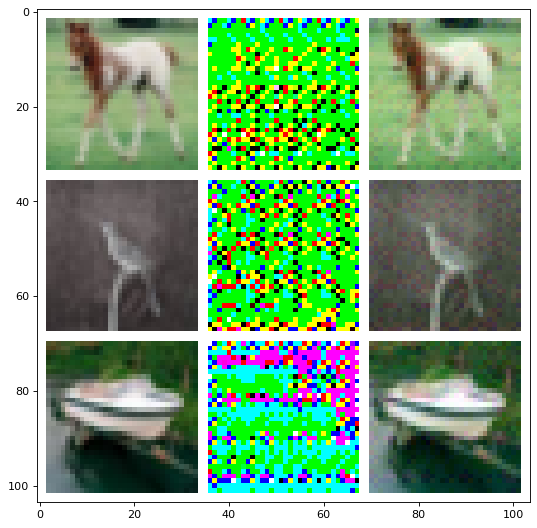

In [12]:
import random
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

def imshow(img):
    fig = plt.figure(figsize=(8, 8), dpi=80, facecolor='w', edgecolor='k')
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    
def get_pairs_of_imgs(idx):
    clean_img = clean_train_dataset.data[idx]
    target = clean_train_dataset.targets[idx]
    unlearnable_img = unlearnable_train_dataset.data[idx]
    clean_img = torchvision.transforms.functional.to_tensor(clean_img)
    unlearnable_img = torchvision.transforms.functional.to_tensor(unlearnable_img)

    x = noise[target].to("cpu")
    x_min = torch.min(x)
    x_max = torch.max(x)
    noise_norm = (x - x_min) / (x_max - x_min)
    noise_norm = torch.clamp(noise_norm, 0, 1)
    return [clean_img, noise_norm, unlearnable_img]
    
selected_idx = [random.randint(0, 50000) for _ in range(3)]
img_grid = []
for idx in selected_idx:
    img_grid += get_pairs_of_imgs(idx)
    

imshow(torchvision.utils.make_grid(torch.stack(img_grid), nrow=3, pad_value=255))



<h3>Train ResNet18 on Unlearnable Dataset</h3>

In [ ]:
from util import AverageMeter

model = ResNet18()
model = model.cuda()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1, weight_decay=0.0005, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=0)

unlearnable_loader = DataLoader(dataset=unlearnable_train_dataset, batch_size=128,
                                shuffle=True, pin_memory=True,
                                drop_last=False, num_workers=6)


for epoch in range(30):
    # Train
    model.train()
    acc_meter = AverageMeter()
    loss_meter = AverageMeter()
    pbar = tqdm(unlearnable_loader, total=len(unlearnable_loader))
    for images, labels in pbar:
        images, labels = images.cuda(), labels.cuda()
        model.zero_grad()
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        _, predicted = torch.max(logits.data, 1)
        acc = (predicted == labels).sum().item()/labels.size(0)
        acc_meter.update(acc)
        loss_meter.update(loss.item())
        pbar.set_description("Acc %.2f Loss: %.2f" % (acc_meter.avg*100, loss_meter.avg))
    scheduler.step()
    # Eval
    model.eval()
    correct, total = 0, 0
    for i, (images, labels) in enumerate(clean_test_loader):
        images, labels = images.cuda(), labels.cuda()
        with torch.no_grad():
            logits = model(images)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    tqdm.write('Clean Accuracy %.2f\n' % (acc*100))
            

Acc 45.61 Loss: 1.59: 100%|██████████| 391/391 [00:40<00:00,  9.66it/s]


Clean Accuracy 23.30



Acc 90.31 Loss: 0.29: 100%|██████████| 391/391 [00:38<00:00, 10.25it/s]


Clean Accuracy 13.14



Acc 98.03 Loss: 0.06: 100%|██████████| 391/391 [00:37<00:00, 10.32it/s]


...

Acc 99.97 Loss: 0.00: 100%|██████████| 391/391 [00:37<00:00, 10.38it/s] 


Clean Accuracy 9.89



  0%|          | 0/391 [00:09<?, ?it/s]


KeyboardInterrupt: 

: 